In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib 
import numpy as np
import os 
from sqlalchemy import create_engine
from urllib.parse import quote_plus 

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

%matplotlib inline

In [2]:
DB_USER = "myvolt_admin" 
DB_PASS = "M%R^N!J%IDKS$8@zya4v"
DB_HOST = "myvolt-db.postgres.database.azure.com"
DB_PORT = "5432"
DB_NAME = "postgres" 

DB_PASS_ENCODED = quote_plus(DB_PASS)

try:
    connection_string = f"postgresql+psycopg2://{DB_USER}:{DB_PASS_ENCODED}@{DB_HOST}:{DB_PORT}/{DB_NAME}?sslmode=require"
    engine = create_engine(connection_string)
    
    with engine.connect() as conn:
        print("¡Conexión a Azure PostgreSQL exitosa!")
        
except Exception as e:
    print(f"Error al conectar a Azure: {e}")

¡Conexión a Azure PostgreSQL exitosa!


In [3]:
query = """
SELECT time, power_w
FROM consumption_data
WHERE id_device = (
    SELECT id_device 
    FROM devices 
    WHERE mac_address = 'B0:A7:32:34:54:9C'
)
ORDER BY time DESC
LIMIT 5000; 
"""

df = pd.read_sql_query(query, con=engine)

print(f"Se cargaron {len(df)} registros (los más recientes) desde la base de datos.")
df.head()

Se cargaron 5000 registros (los más recientes) desde la base de datos.


,time,power_w
0,2025-11-11 02:34:51.466712+00:00,233.77
1,2025-11-11 02:34:51.252578+00:00,192.72
2,2025-11-11 02:34:51.042075+00:00,194.47
3,2025-11-11 02:34:50.824002+00:00,230.22
4,2025-11-11 02:34:50.612491+00:00,198.99


In [4]:
datos_para_modelo = df[['power_w']]
scaler = MinMaxScaler()
datos_escalados = scaler.fit_transform(datos_para_modelo)

print("Datos escalados (convertidos de 0 a 1):")
print(datos_escalados[:5])

Datos escalados (convertidos de 0 a 1):
[[0.93379322]
 [0.76623536]
 [0.77337851]
 [0.91930283]
 [0.79182824]]


In [5]:
input_layer = Input(shape=(1,))
encoder = Dense(8, activation='relu')(input_layer)
encoder = Dense(4, activation='relu')(encoder) 
decoder = Dense(8, activation='relu')(encoder)
decoder = Dense(1, activation='sigmoid')(decoder) 
autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mae', metrics=['mae'])
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101 (404.00 B)

 Trainable params: 101 (404.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
historial = autoencoder.fit(
    datos_escalados, 
    datos_escalados, 
    epochs=50,       
    batch_size=32,
    shuffle=True,
    validation_split=0.1 
)

print("¡Autoencoder de Consola de Videojuegos entrenado!")

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3200 - mae: 0.3200 - val_loss: 0.2174 - val_mae: 0.2174
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0966 - mae: 0.0966 - val_loss: 0.0248 - val_mae: 0.0248
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0183 - mae: 0.0183 - val_loss: 0.0154 - val_mae: 0.0154
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0156 - mae: 0.0156 - val_loss: 0.0147 - val_mae: 0.0147
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0152 - mae: 0.0152 - val_loss: 0.0144 - val_mae: 0.0144
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0149 - mae: 0.0149 - val_loss: 0.0142 - val_mae: 0.0142
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0144 - mae: 0.0144 - val_loss: 0.0141 - val_mae: 0.0141
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0144 - mae: 0.0144 - val_loss: 0.0140 - val_mae: 0.0140
Epoch 9/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - lo

In [7]:
final_error = historial.history['val_loss'][-1]
final_precision_pct = (1 - final_error) * 100

print(f"Resultados del Entrenamiento de la Red Neuronal (Consola):")
print(f"Error Final (val_loss): {final_error:.6f} (o {final_error*100:.2f}%)")
print(f"Precisión de Reconstrucción Final: {final_precision_pct:.2f}%")

Resultados del Entrenamiento de la Red Neuronal (Consola):
Error Final (val_loss): 0.004385 (o 0.44%)
Precisión de Reconstrucción Final: 99.56%


In [8]:
datos_reconstruidos = autoencoder.predict(datos_escalados)
errores = mean_absolute_error(datos_escalados.T, datos_reconstruidos.T, multioutput='raw_values')
df['error_nn'] = errores
umbral = np.percentile(df['error_nn'], 98)

print(f"Error de reconstrucción promedio: {np.mean(df['error_nn'])}")
print(f"UMBRAL DE ANOMALÍA (Consola) establecido en: {umbral}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Error de reconstrucción promedio: 0.004531030404969089
UMBRAL DE ANOMALÍA (Consola) establecido en: 0.021518482731441448


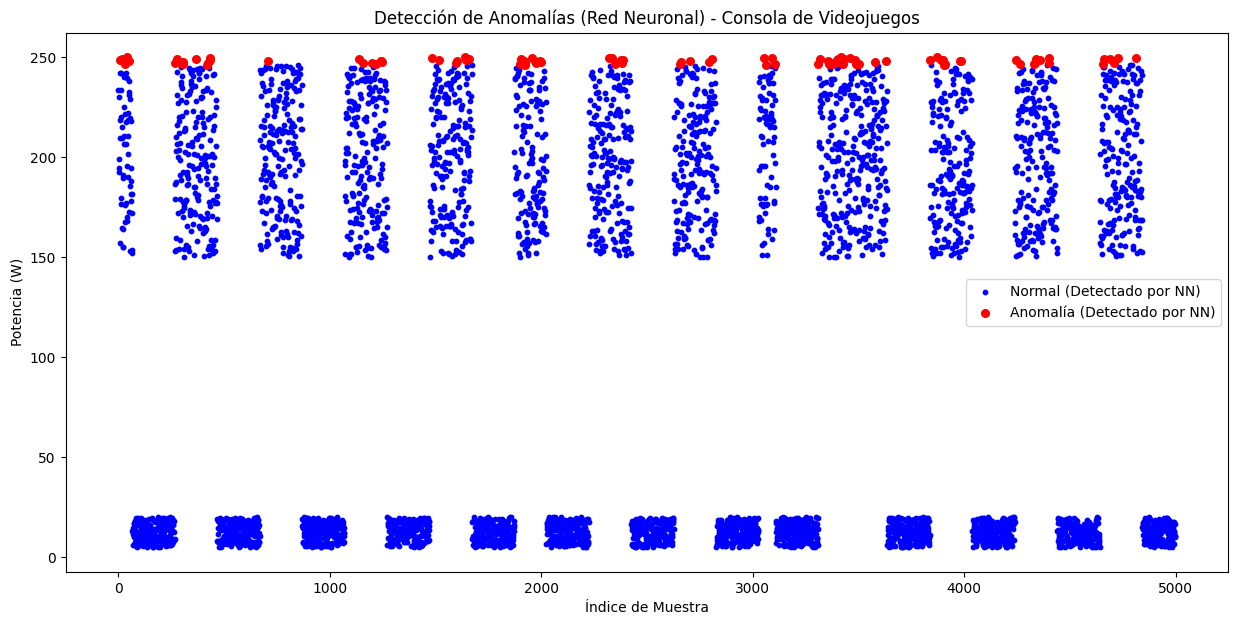

In [9]:
df['anomalia_nn'] = df['error_nn'] > umbral
df_normal = df[df['anomalia_nn'] == False]
df_anomalo = df[df['anomalia_nn'] == True]

plt.figure(figsize=(15, 7))
# Deberías ver dos nubes azules: una en 5-20W y otra en 150-250W
plt.scatter(df_normal.index, df_normal['power_w'], 
            c='blue', label='Normal (Detectado por NN)', s=10)
plt.scatter(df_anomalo.index, df_anomalo['power_w'], 
            c='red', label='Anomalía (Detectado por NN)', s=30)

plt.title('Detección de Anomalías (Red Neuronal) - Consola de Videojuegos')
plt.xlabel('Índice de Muestra')
plt.ylabel('Potencia (W)')
plt.legend()
plt.show()

In [10]:
# 1. Definimos las rutas de salida
ruta_modelo_nn = '../neural_network/consola_autoencoder_v1.h5'
ruta_scaler_nn = '../scaler/consola_scaler_v1.pkl'

# 2. Nos aseguramos de que las carpetas existan
os.makedirs(os.path.dirname(ruta_modelo_nn), exist_ok=True)
os.makedirs(os.path.dirname(ruta_scaler_nn), exist_ok=True)

# 3. Guardar el modelo de Red Neuronal (formato .h5)
autoencoder.save(ruta_modelo_nn)

# 4. Guardar el escalador (el que convierte de 0-250 a 0-1)
joblib.dump(scaler, ruta_scaler_nn)

print(f"¡Modelo de Consola guardado en: {ruta_modelo_nn}!")
print(f"¡Escalador de Consola guardado en: {ruta_scaler_nn}!")

¡Modelo de Consola guardado en: ../neural_network/consola_autoencoder_v1.h5!
¡Escalador de Consola guardado en: ../scaler/consola_scaler_v1.pkl!
